In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import seaborn as sn

from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,NaN,35,0,33.6,0.627,50,1
1,1,85.0,NaN,29,0,26.6,0.351,31,0
2,8,183.0,64.0,0,0,23.3,0.672,32,1
3,1,89.0,66.0,23,94,28.1,0.167,21,0
4,0,137.0,40.0,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.Outcome.value_counts()

,count
Outcome,
0,500
1,268


negligible imbalance.Not worried about that


In [ ]:


df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,4
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:

# Fill null values with the mean of the respective columns
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,69.069372,35,0,33.6,0.627,50,1
1,1,85.0,69.069372,29,0,26.6,0.351,31,0
2,8,183.0,64.000000,0,0,23.3,0.672,32,1
3,1,89.0,66.000000,23,94,28.1,0.167,21,0
4,0,137.0,40.000000,35,168,43.1,2.288,33,1


In [ ]:

correlation_matrix = df.corr()


correlation_matrix


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130059,0.140442,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.130059,1.000000,0.153517,0.058709,0.313515,0.225571,0.135901,0.253936,0.462804
BloodPressure,0.140442,0.153517,1.000000,0.209925,0.090316,0.280549,0.042383,0.239848,0.065389
SkinThickness,-0.081672,0.058709,0.209925,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.313515,0.090316,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.225571,0.280549,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.135901,0.042383,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.253936,0.239848,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.462804,0.065389,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

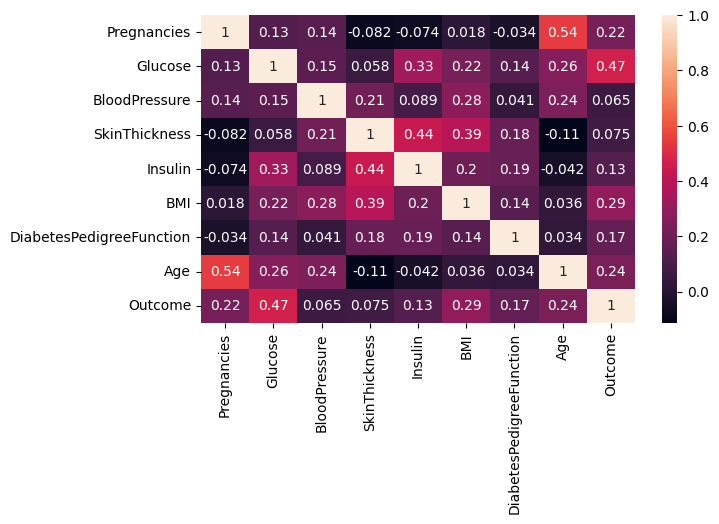

In [ ]:
plt.figure(figsize=(7,4))
sn.heatmap(correlation_matrix,annot = True)

Test Train Spllit

In [ ]:
X = df.drop("Outcome",axis="columns")
y = df.Outcome

Now we will use MinMaxScaler.

In [ ]:
from sklearn.preprocessing  import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:3]


array([[0.35294118, 0.74371859, 0.56614239, 0.35353535, 0.        ,
        0.50074516, 0.23441503, 0.48333333],
       [0.05882353, 0.42713568, 0.56614239, 0.29292929, 0.        ,
        0.39642325, 0.11656704, 0.16666667],
       [0.47058824, 0.91959799, 0.52459016, 0.        , 0.        ,
        0.34724292, 0.25362938, 0.18333333]])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=10,train_size = 0.7)

0.7229437229437229
              precision    recall  f1-score   support

           0       0.74      0.85      0.79       144
           1       0.67      0.52      0.58        87

    accuracy                           0.72       231
   macro avg       0.71      0.68      0.69       231
weighted avg       0.72      0.72      0.71       231



<Axes: >

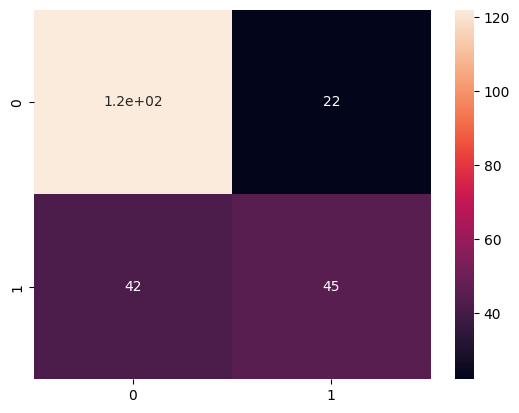

In [ ]:
from sklearn.naive_bayes import GaussianNB


clf = GaussianNB()

clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print(clf.score(X_test,y_test))

print(classification_report(y_test,y_pred))




cm = confusion_matrix(y_test,y_pred)
sn.heatmap(cm,annot = True)


0.6926406926406926
              precision    recall  f1-score   support

           0       0.70      0.90      0.79       144
           1       0.68      0.34      0.46        87

    accuracy                           0.69       231
   macro avg       0.69      0.62      0.62       231
weighted avg       0.69      0.69      0.66       231



<Axes: >

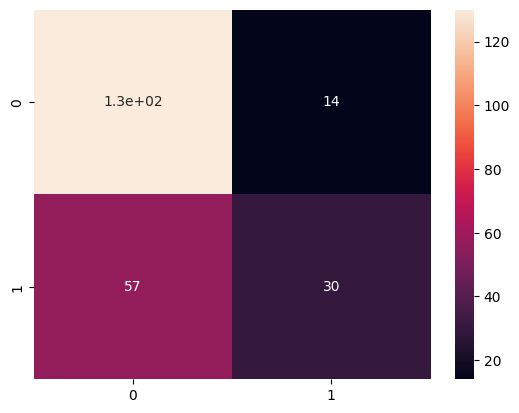

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
print(knn.score(X_test,y_test))
print(classification_report(y_test,knn.predict(X_test)))
cm = confusion_matrix(y_test,knn.predict(X_test))
sn.heatmap(cm,annot = True)

0.6926406926406926
              precision    recall  f1-score   support

           0       0.75      0.76      0.76       144
           1       0.60      0.57      0.58        87

    accuracy                           0.69       231
   macro avg       0.67      0.67      0.67       231
weighted avg       0.69      0.69      0.69       231



<Axes: >

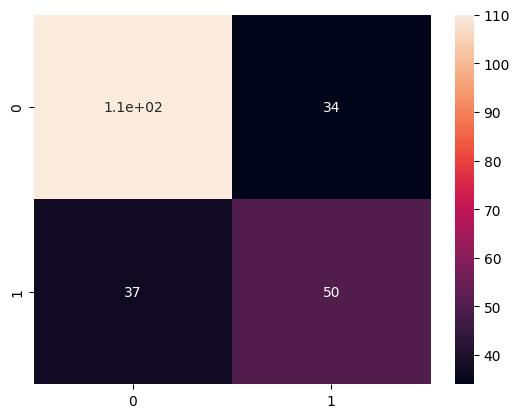

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
print(dtc.score(X_test,y_test))
print(classification_report(y_test,dtc.predict(X_test)))
cm = confusion_matrix(y_test,dtc.predict(X_test))
sn.heatmap(cm,annot = True)


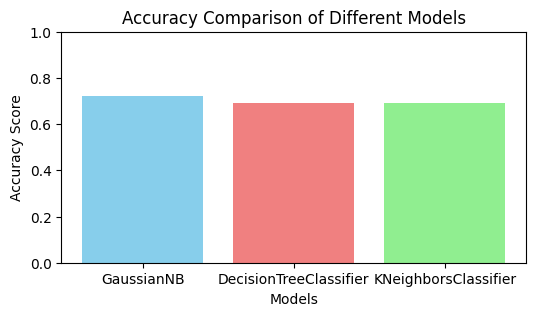

In [ ]:

models = ['GaussianNB', 'DecisionTreeClassifier', 'KNeighborsClassifier']
accuracy_scores = [clf.score(X_test,y_test), dtc.score(X_test,y_test), knn.score(X_test,y_test)]

plt.figure(figsize=(6, 3))
plt.bar(models, accuracy_scores, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.title("Accuracy Comparison of Different Models")
plt.ylim(0, 1)
plt.show()